# Loan Approval Prediction System using Gradient Boosting Models

This project presents a complete end-to-end machine learning workflow designed to predict whether a loan application should be approved or rejected based on applicant and loan characteristics.

Starting with exploratory data analysis (EDA), we examined key trends in demographic and financial variables, explored relationships between features and loan outcomes, and addressed class imbalance to ensure fair model performance.

We then developed and compared multiple gradient boosting frameworks ( including Gradient Boosting, XGBoost, LightGBM, and CatBoost) to identify the most efficient and accurate approach. After careful hyperparameter tuning and evaluation, XGBoost emerged as the optimal model, balancing speed, interpretability, and predictive power.

The final model was deployed through an interactive Gradio application, allowing users to input borrower details and receive real-time loan approval predictions. This demonstrates how machine learning can effectively support data-driven financial decision-making in lending and risk assessment.

# Environment Setup

In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [4]:
df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/Scorecard_Project/loan_data.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


# Data Exploration and Feature Selection

This section explores the dataset in depth to understand variable distributions, relationships, and potential predictors of insurance fraud. Through univariate, bivariate, and multivariate analyses, key patterns and correlations are identified. Statistical tools such as VIF, correlation heatmaps, and hierarchical clustering are used to detect multicollinearity and redundancy.
Based on these insights, non-informative or overlapping variables are removed, resulting in a refined set of independent, meaningful features ready for logistic regression modeling.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
df.dtypes.value_counts()

,count
float64,6
object,5
int64,3


In [7]:
len(df.select_dtypes(['object']).applymap(type).value_counts())

/tmp/ipython-input-2890713169.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  len(df.select_dtypes(['object']).applymap(type).value_counts())


1

In [8]:
df.isnull().any(axis=0).any()

np.False_

In [9]:
print(f"{len(df[df.duplicated()])} entries are duplicates")

0 entries are duplicates


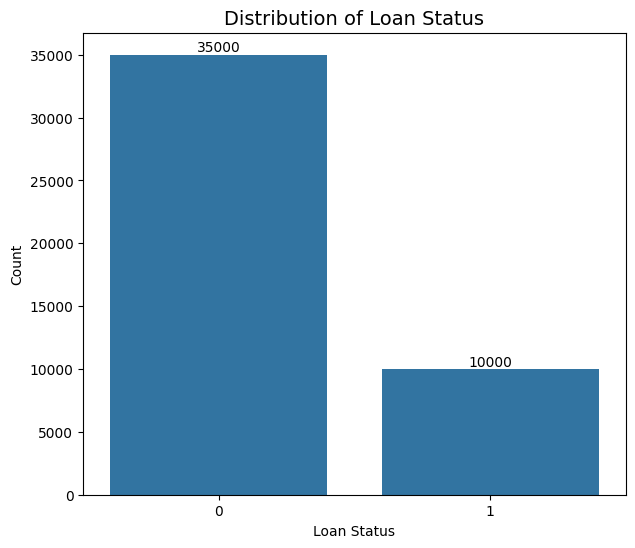

In [10]:
plt.figure(figsize=(7,6))
ax = sns.countplot(data=df, x='loan_status')
ax.bar_label(ax.containers[0])

ax.set_title('Distribution of Loan Status', fontsize=14)
ax.set_xlabel('Loan Status')
ax.set_ylabel('Count')
plt.show()


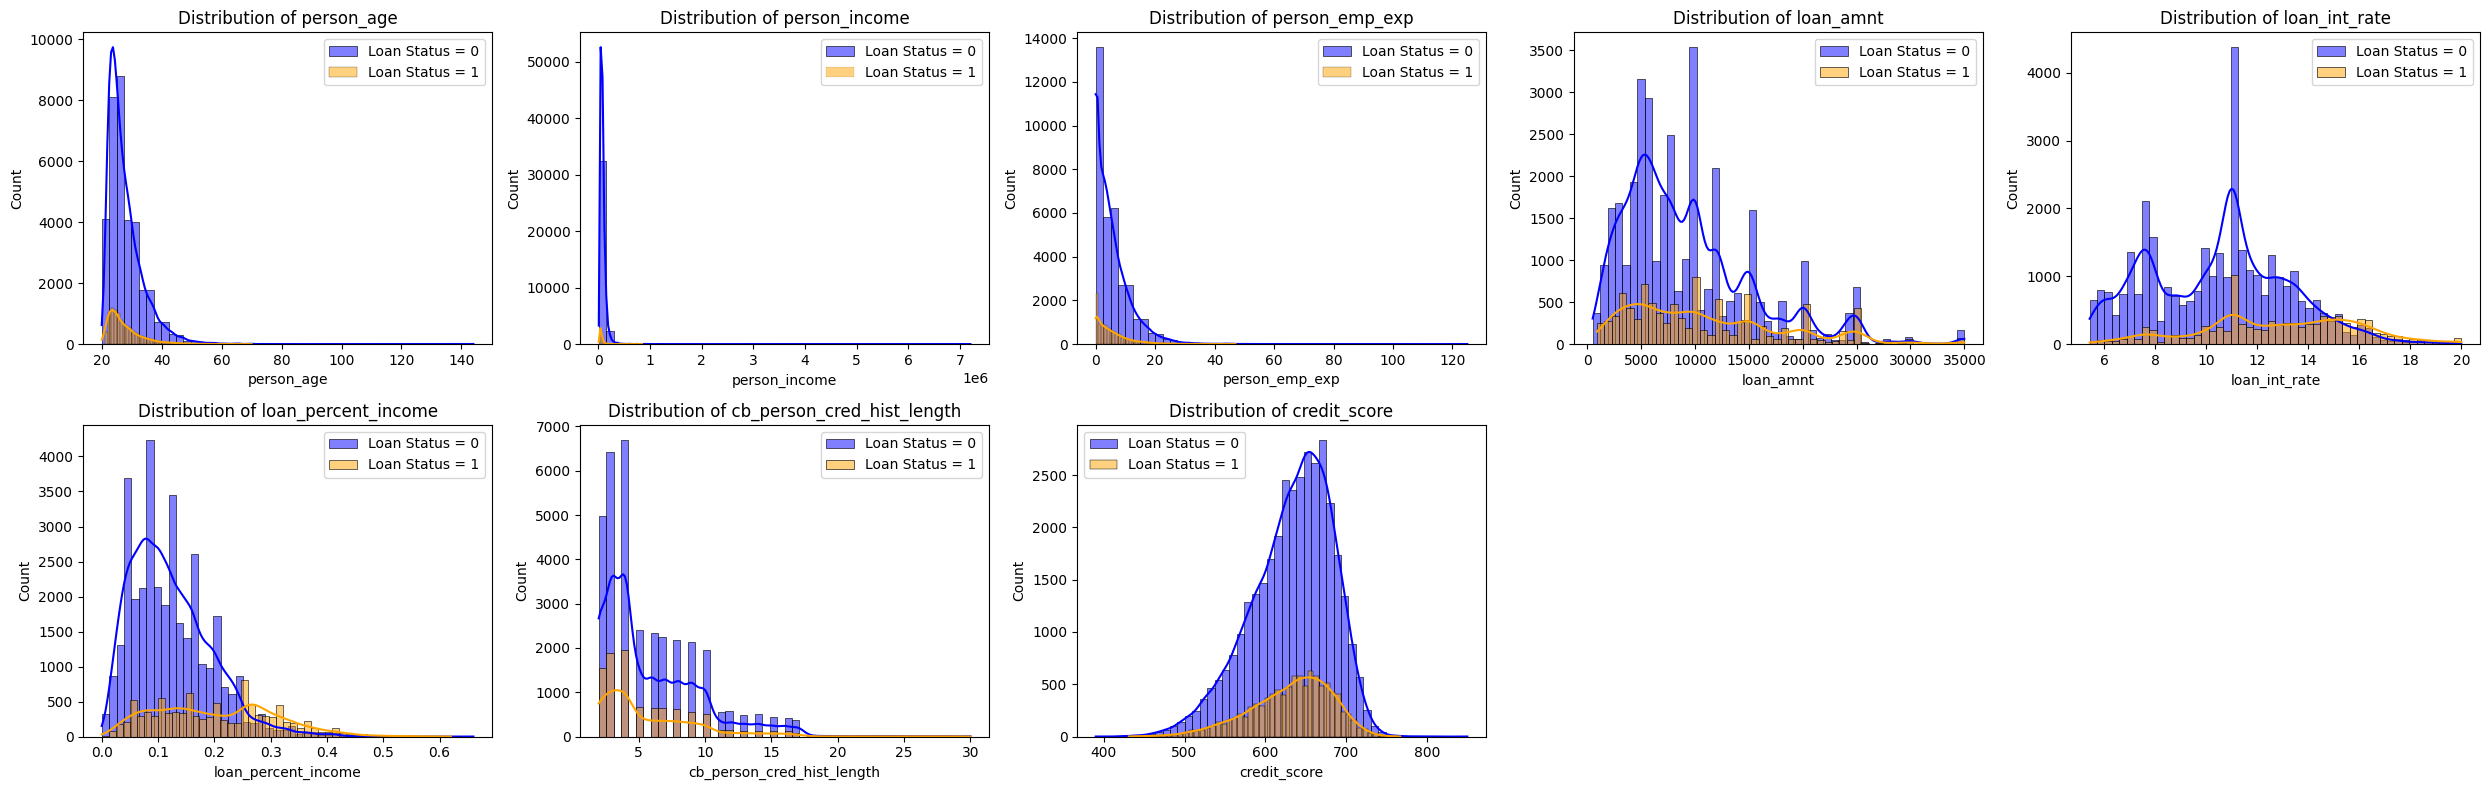

In [11]:
def plot_numerical_features_grid(df, target='loan_status', ncols=4, bins=50):
    features = df.select_dtypes(include=["int", "float"]).columns.drop(target)
    n_features = len(features)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.histplot(df[df[target] == 0][feature],
                     bins=bins, color='blue', label='Loan Status = 0',
                     kde=True, ax=ax)
        sns.histplot(df[df[target] == 1][feature],
                     bins=bins, color='orange', label='Loan Status = 1',
                     kde=True, ax=ax)

        ax.set_title(f'Distribution of {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Count')
        ax.legend()

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_numerical_features_grid(df, target='loan_status', ncols=5)


Key Observations

* Person Age (person_age): Most borrowers are young adults between 20–40 years. Defaults are slightly higher among younger borrowers, suggesting limited credit history or lower financial stability.

* Person Income (person_income): Income is highly skewed, with most borrowers earning below 100,000. Defaulting borrowers tend to have lower income ranges.

* Employment Experience (person_emp_exp): A large proportion of borrowers have fewer than 10 years of employment experience, with slightly higher default rates observed for those with shorter employment histories.

* Loan Amount (loan_amnt): Loan amounts are right-skewed, concentrated below 20,000. Higher loan amounts correlate with a marginal increase in default frequency.

* Interest Rate (loan_int_rate): Defaulted loans tend to have higher interest rates, indicating that riskier borrowers are often charged more, leading to greater repayment difficulty.

* Loan Percent Income (loan_percent_income): Borrowers allocating a larger portion of their income to loan repayments are more likely to default, highlighting potential over-leverage.

* Credit History Length (cb_person_cred_hist_length): Longer credit histories are associated with fewer defaults, as experienced borrowers are better evaluated by lenders.

* Credit Score (credit_score): A strong negative correlation exists between credit score and default probability, defaulted borrowers tend to cluster at lower credit score ranges (below 600)

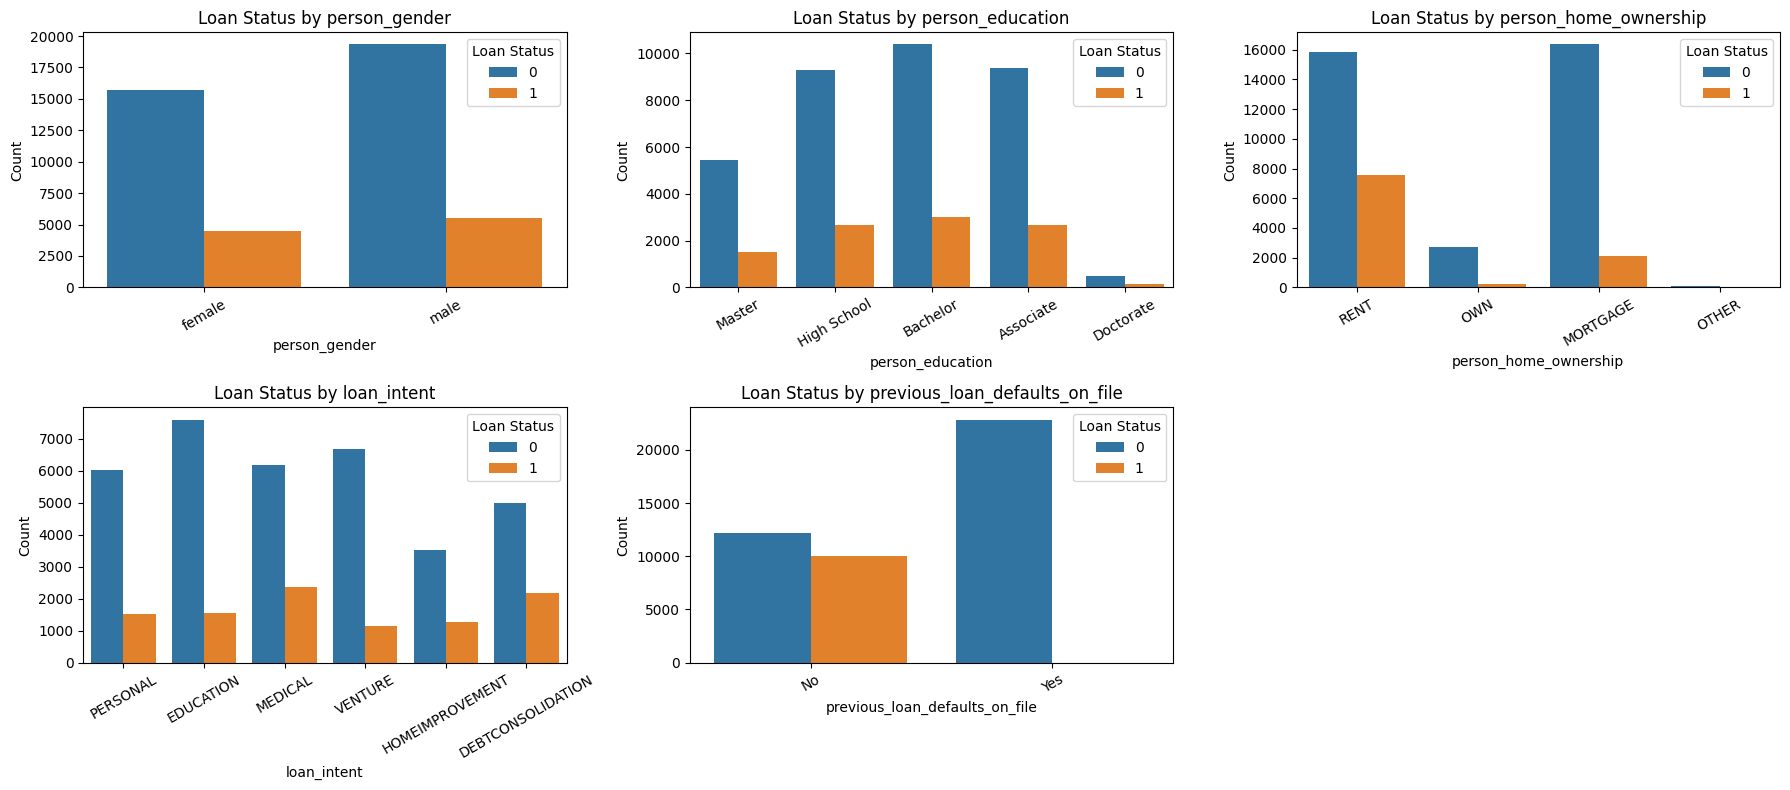

In [12]:
def plot_categorical_features_grid(df, target='loan_status', ncols=3):
    features = df.select_dtypes(include=["object", "category"]).columns
    n_features = len(features)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.countplot(data=df, x=feature, hue=target, ax=ax)
        ax.set_title(f'Loan Status by {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Count')
        ax.legend(title='Loan Status', labels=['0', '1'])
        ax.tick_params(axis='x', rotation=30)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_categorical_features_grid(df, target='loan_status', ncols=3)


Key Observations

* Gender (person_gender): Both male and female borrowers exhibit similar patterns of loan repayment, though males show a slightly higher default proportion. This suggests that gender has only a limited effect on predicting loan outcomes.

* Education Level (person_education): Borrowers with higher educational attainment (Bachelor’s or Master’s degrees) are less likely to default compared to those with lower education levels such as high school or associate degrees. This may indicate that education contributes to better employment prospects, income stability, and financial literacy.

* Home Ownership (person_home_ownership): Individuals who own or mortgage their homes tend to have lower default rates, while renters exhibit higher default probabilities. Homeownership can be interpreted as a proxy for financial stability and access to assets, both of which reduce credit risk.

* Loan Intent (loan_intent): The purpose of the loan plays a substantial role in repayment behavior. Borrowers seeking loans for debt consolidation and home improvement display relatively higher default tendencies, while those borrowing for education or medical purposes have stronger repayment performance.
This suggests that loans used for productive or essential purposes (education, health) tend to perform better than those for discretionary spending.

* Previous Loan Defaults (previous_loan_defaults_on_file): This feature shows a strong association with loan outcomes, however, upon inspection, the relationship appears inverted. The "Yes" category (indicating prior defaults) surprisingly contains more non-default loans, while the "No" group shows a higher rate of defaults. This inconsistency suggests that the feature’s encoding may be reversed, where "Yes" may actually represent no previous defaults and "No" may represent a history of default.

Before model training, it is crucial to verify and recode this variable to ensure the semantic meaning aligns correctly. A mislabel here could significantly distort model interpretation and feature importance rankings.

In [13]:
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 'No', 'No': 'Yes'})


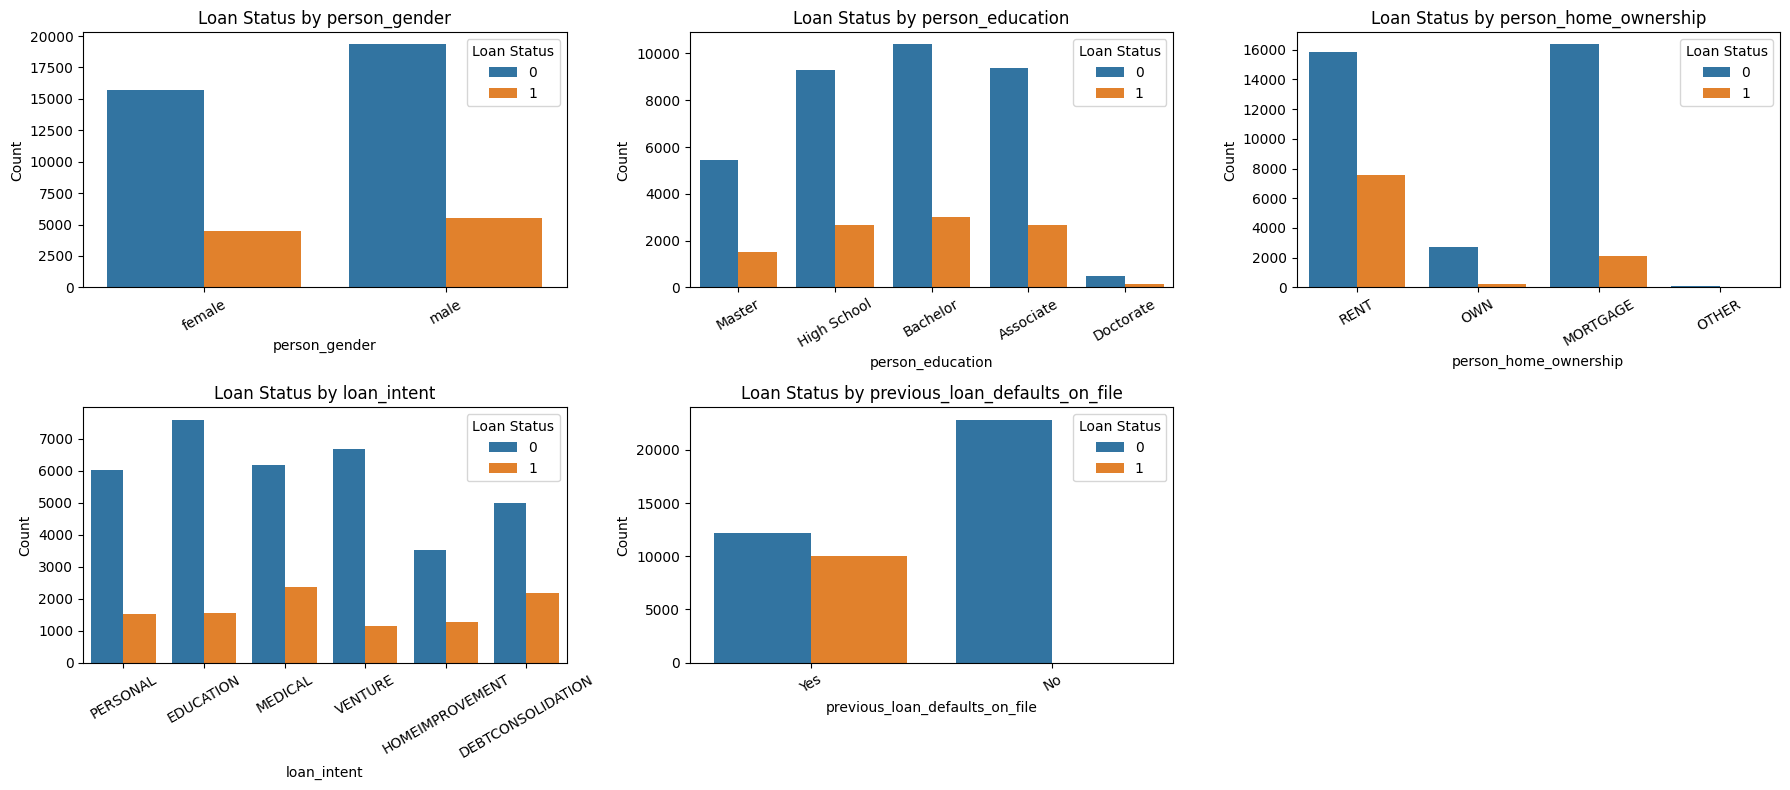

In [14]:
plot_categorical_features_grid(df, target='loan_status', ncols=3)


In [15]:
cat_cardinality = df.select_dtypes(['object']).nunique().sort_values()

low_cardinality = [col for col in cat_cardinality.index if cat_cardinality[col] <= 10]
medium_cardinality = [col for col in cat_cardinality.index if 10 < cat_cardinality[col] <= 30]
high_cardinality = [col for col in cat_cardinality.index if cat_cardinality[col] > 30]

print("Low-cardinality features:", low_cardinality)
print("Medium-cardinality features:", medium_cardinality)
print("High-cardinality features:", high_cardinality)

Low-cardinality features: ['person_gender', 'previous_loan_defaults_on_file', 'person_home_ownership', 'person_education', 'loan_intent']
Medium-cardinality features: []
High-cardinality features: []


In [16]:
df_encoded = pd.get_dummies(df, columns=['person_gender',
                                         'previous_loan_defaults_on_file',
                                         'person_home_ownership',
                                         'person_education',
                                         'loan_intent'],
                            drop_first=True)

In [17]:
df_encoded.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_home_ownership_RENT,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,True,False,False,False,True,False,False,False,True,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,False,False,True,False,True,False,False,False,False
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,False,True,False,False,False,True,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,False,...,True,True,False,False,False,False,False,True,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,True,...,True,False,False,False,True,False,False,True,False,False


To prepare categorical variables for correlation analysis and modeling, features were classified based on their cardinality.
Since all categorical features exhibited low cardinality (≤10 unique categories), they were one-hot encoded using pd.get_dummies() with drop_first=True. This approach converts categorical data into numeric form while preventing multicollinearity, allowing for seamless integration into the correlation heatmap and subsequent modeling stages.

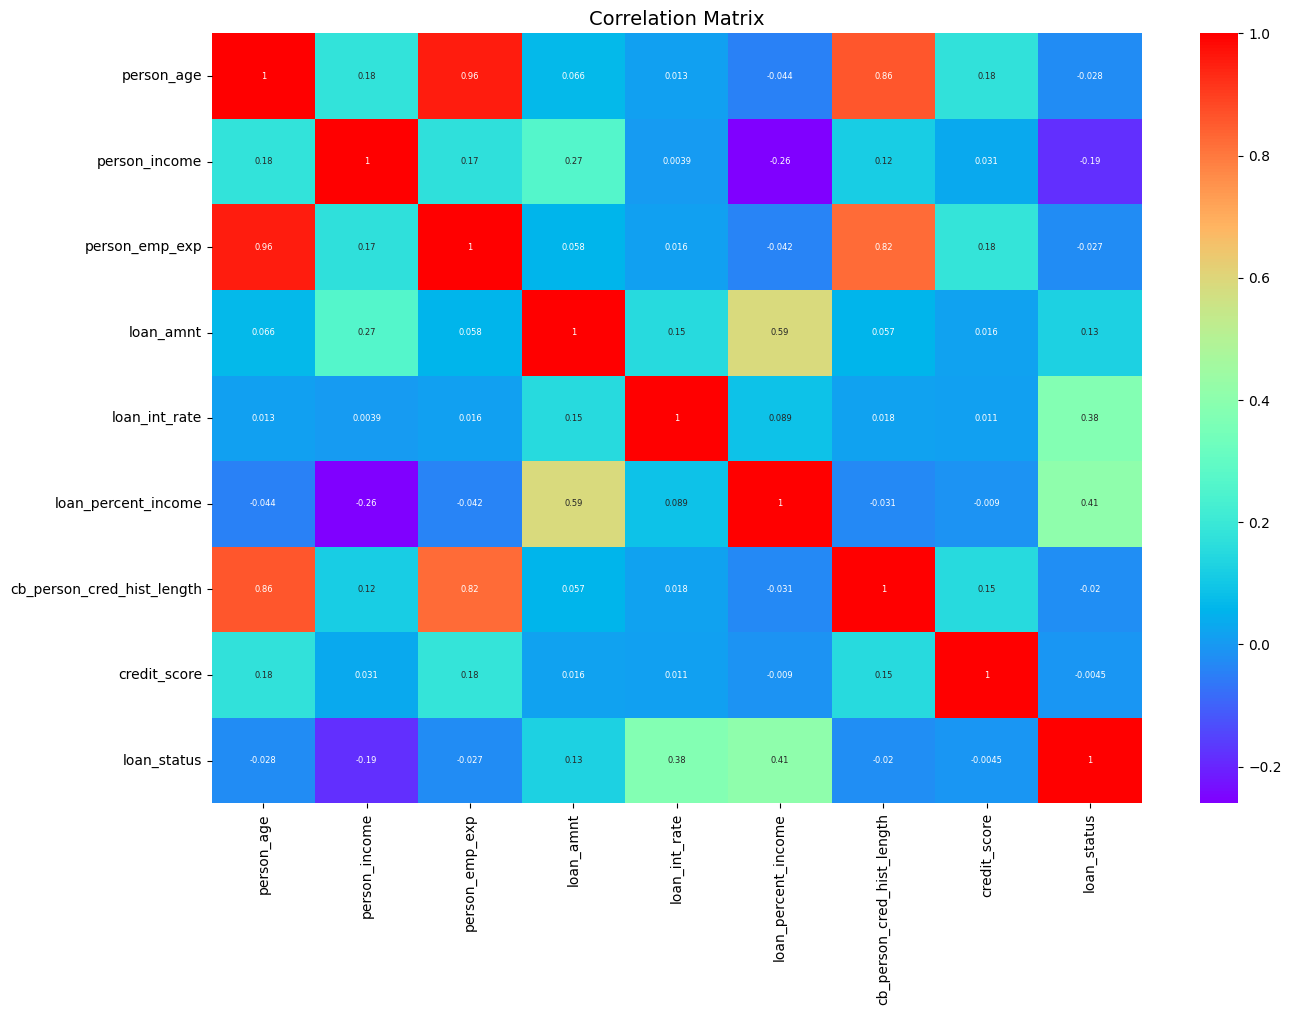

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

target_col = "loan_status"

df_corr_ready = df_encoded.select_dtypes(include=["int", "float"])

X = df_corr_ready.drop(columns=[target_col])
y = df_corr_ready[target_col]

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

df_balanced = pd.concat([
    pd.DataFrame(X_res, columns=X.columns),
    pd.Series(y_res, name=target_col)
], axis=1)

corr = df_balanced.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, annot_kws={'size': 6}, cmap='rainbow')
plt.title("Correlation Matrix", fontsize=14)
plt.show()


The heatmap above shows the relationships between numerical features and the target variable, loan_status.

Key points:

* Strong correlations exist between person_age, person_emp_exp, and cb_person_cred_hist_length, meaning older borrowers tend to have longer work and credit histories.

* Moderate correlations are seen between loan_amnt and loan_percent_income, as well as between loan_int_rate and loan_status.

* Higher interest rates and higher loan-to-income ratios are linked to a greater chance of loan default.

* Most other features show weak correlations with the target, suggesting that nonlinear models like Gradient Boosting will help capture deeper patterns.

Overall, the correlation heatmap helps identify which variables are related and flags potential multicollinearity among similar features

/tmp/ipython-input-999943390.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


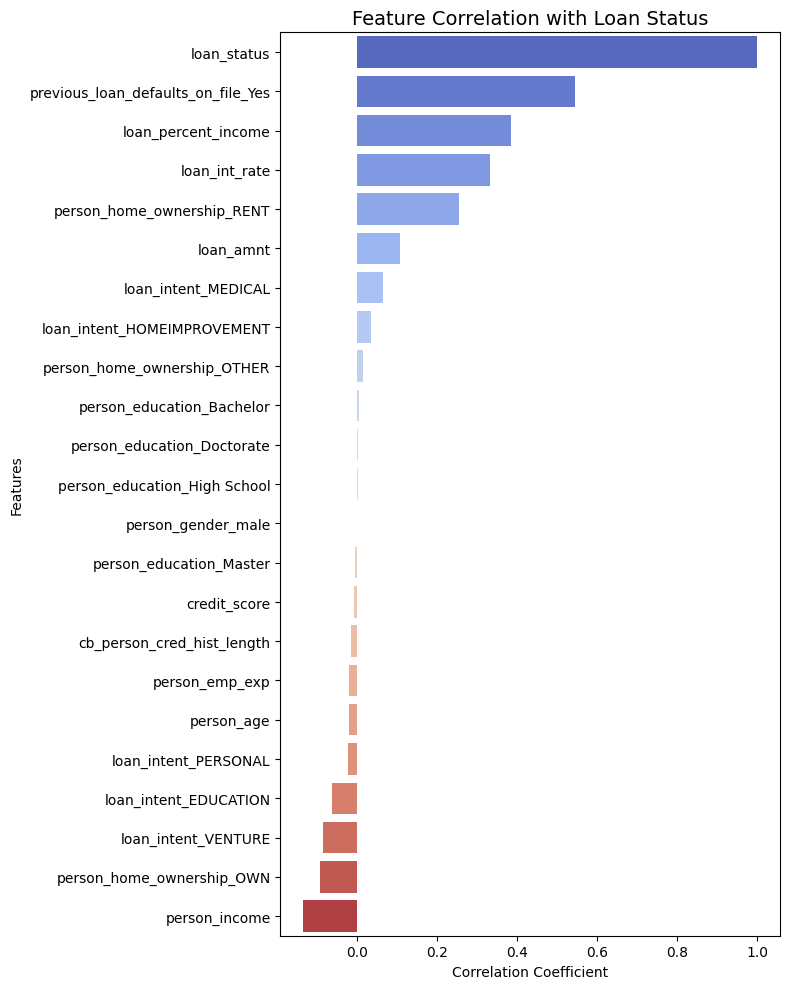

In [19]:
plt.figure(figsize=(8, 10))

corr_target = df_encoded.corr()['loan_status'].sort_values(ascending=False)

sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')

plt.title("Feature Correlation with Loan Status", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


Key observations:

* Previous loan defaults show the strongest positive correlation with loan status, confirming that borrowers with past defaults are more likely to default again.

* Loan percent income and loan interest rate also have moderate positive correlations, meaning higher debt-to-income ratios and higher interest rates are linked to increased default risk.

* Person income has a weak negative correlation, indicating that higher income slightly reduces the chance of default.

* Most other features, such as education level and gender, show minimal correlation with the target.

This visualization helps highlight which features are most relevant for predicting loan outcomes and provides direction for feature selection in the modeling stage.

In [20]:
cols_to_drop = ['person_emp_exp', 'cb_person_cred_hist_length', 'loan_amnt']
df_model = df_encoded.drop(columns=cols_to_drop)


To avoid redundancy and simplify the model:

* person_emp_exp and cb_person_cred_hist_length were dropped due to strong correlations with person_age.

* loan_amnt was removed since its information is already captured by loan_percent_income.

This helps reduce multicollinearity and keeps only the most informative features for modeling.

# Train Test Split

In [21]:
X = df_model.drop(columns="loan_status")
y = df_model["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Baseline Model: Gradient Boosting Classifier (Scikit-Learn)

The first model tested is a Gradient Boosting Classifier using Scikit-Learn’s implementation.

A randomized hyperparameter search with Stratified 3-Fold Cross-Validation was used to tune model parameters efficiently while maintaining balanced class splits.

The tuning process explores different values for:

* max_depth: controls tree complexity (range 5–20)

* learning_rate: controls the step size for each boosting stage

* n_estimators: the number of boosting iterations (range 50–500)

Model performance is evaluated using ROC-AUC to account for class imbalance.
The best-performing configuration and training time are reported below.

In [22]:
import time
from scipy.stats import randint
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

def train_model(model):
    start = time.time()

    param_dist = {
        'max_depth': randint(5, 20),
        'learning_rate': [0.01, 0.05, 0.1, 0.25, 0.5],
        'n_estimators': randint(50, 500)
    }

    skcv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    rand_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,
        cv=skcv,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    rand_search.fit(X_train, y_train)

    print('Best hyperparameters:', rand_search.best_params_)
    print(f"Training completed in {time.time() - start:.2f} seconds")

    return rand_search.best_estimator_

gb = GradientBoostingClassifier(random_state=42)
model_sklearn = train_model(gb)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 11, 'n_estimators': 380}
Training completed in 1940.79 seconds


The baseline Gradient Boosting model completed randomized hyperparameter tuning across 10 parameter combinations using 3-fold cross-validation.
The best configuration achieved:

* Learning rate: 0.1

* Max depth: 11

* Estimators: 380

* Training time: ~34 minutes

This model will serve as the baseline for comparison against XGBoost, LightGBM, and CatBoost in the following sections.

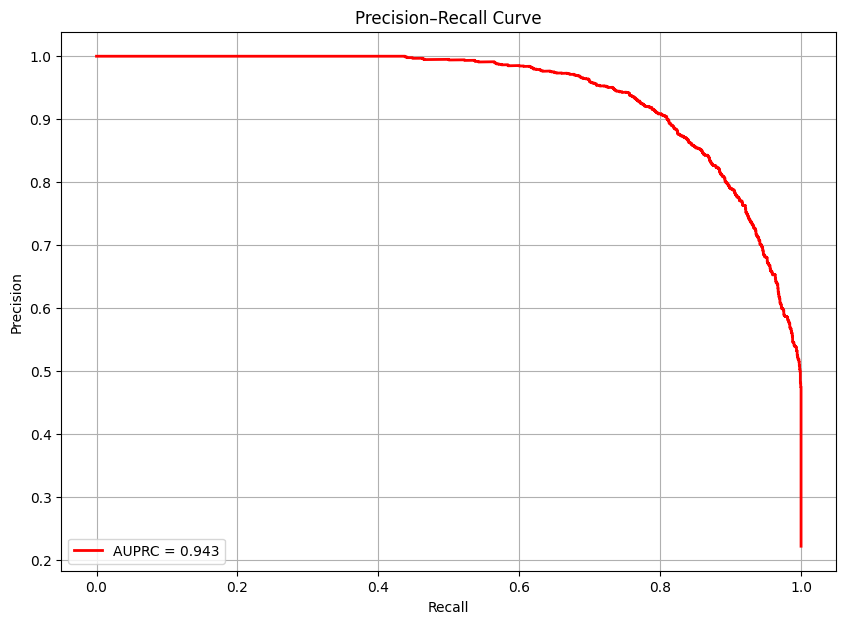

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def evaluate(model):
    plt.figure(figsize=(10,7))

    y_pred_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    auprc = average_precision_score(y_test, y_pred_prob)

    plt.plot(recall, precision, label=f'AUPRC = {auprc:.3f}', color='red', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()

evaluate(model_sklearn)


The Precision–Recall (PR) curve above shows that the Gradient Boosting model performs exceptionally well, achieving an AUPRC of 0.943.
This indicates that the model maintains high precision even at high recall levels, meaning it correctly identifies most loan defaults while minimizing false positives.

The smooth shape of the curve and the high AUPRC score demonstrate strong model reliability and good balance between precision and recall, which is essential for imbalanced classification problems such as loan default prediction

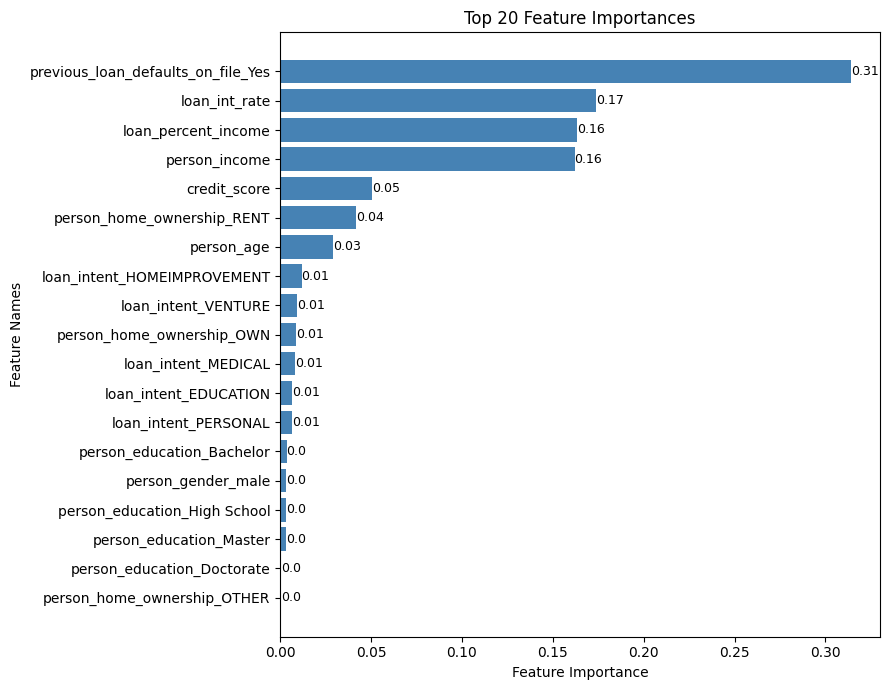

In [24]:
import matplotlib.pyplot as plt

def plot_feature_importances(model):
    plt.figure(figsize=(9, 7))

    if model.__class__.__module__ == "lightgbm.sklearn":
        feature_names = model.feature_name_
    elif model.__class__.__module__ == "catboost.core":
        feature_names = model.feature_names_
    else:
        feature_names = model.feature_names_in_

    sorted_features = sorted(zip(feature_names, model.feature_importances_), key=lambda x: x[1])
    sorted_names, sorted_imp = zip(*sorted_features[-20:])

    plt.barh(range(len(sorted_imp)), sorted_imp, align='center', color='steelblue')
    for i, v in enumerate(sorted_imp):
        plt.text(v, i, str(round(v, 2)), va='center', ha='left', fontsize=9)

    plt.yticks(range(len(sorted_imp)), sorted_names)
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature Names')
    plt.title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()

plot_feature_importances(model_sklearn)


The Gradient Boosting model identifies previous loan defaults, loan interest rate, and loan percent income as the most influential predictors of loan default.
These features indicate that borrower credit history and financial stress indicators are the strongest determinants of loan risk.
Other factors such as income level, credit score, and home ownership type contribute moderately, while demographic features like education and gender show minimal impact on the prediction outcome.

This ranking confirms that the model’s key drivers align with financial intuition, defaults are most strongly tied to past credit behavior and repayment capacity.

# XGBoost Model

Next, the XGBoost (Extreme Gradient Boosting) algorithm was implemented to build a more efficient and scalable version of the gradient boosting model.
XGBoost uses advanced regularization, optimized tree growth, and parallelized training, which often leads to better performance and faster convergence compared to traditional Gradient Boosting.

The same hyperparameter tuning and evaluation approach were applied for consistency with the baseline model.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 358}
Training completed in 60.67 seconds


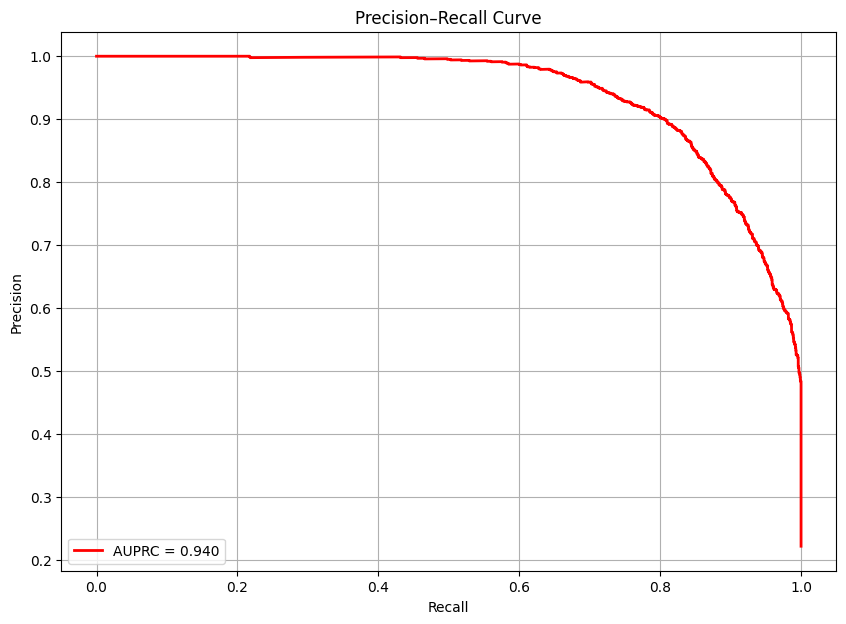

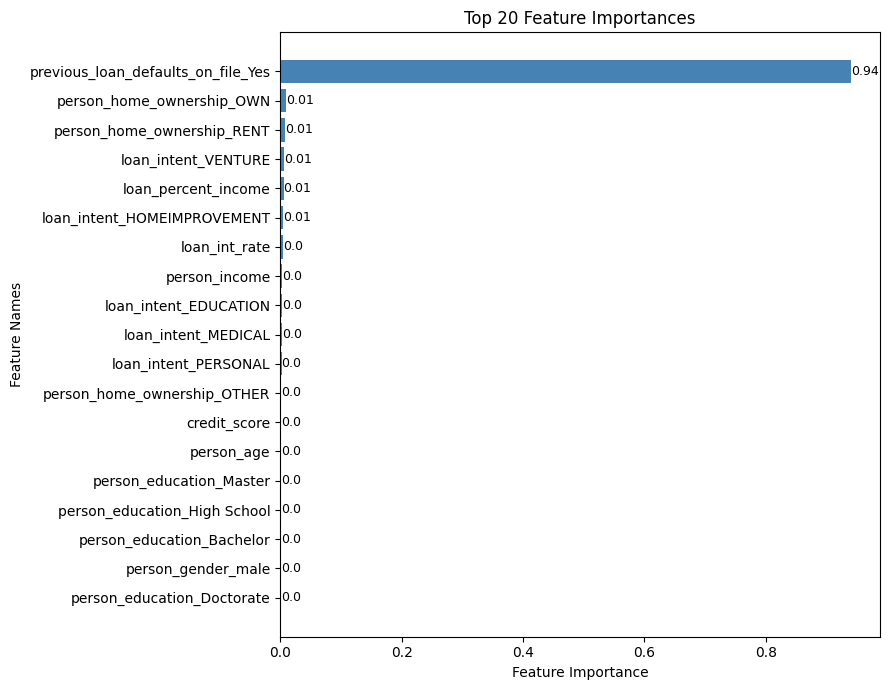

In [25]:
!pip install xgboost lightgbm catboost
from xgboost import XGBClassifier


xgb = XGBClassifier(random_state=42)
model_xgb = train_model(xgb)
evaluate(model_xgb)
plot_feature_importances(model_xgb)


## Model Evaluation

The XGBoost model achieved an AUPRC of 0.940, performing on par with the baseline Gradient Boosting model while training more efficiently.
The curve shows that XGBoost maintains high precision across nearly all recall levels, confirming its ability to balance false positives and false negatives effectively.

In terms of feature importance, previous loan defaults overwhelmingly dominate as the most significant predictor, followed by home ownership type and loan-related financial ratios.
This result reinforces the strong influence of borrower credit history and financial capacity on loan default risk.

# LightGBM Model

The next model tested is LightGBM (Light Gradient Boosting Machine), a highly efficient gradient boosting framework optimized for speed and performance on large datasets. LightGBM uses leaf-wise tree growth, histogram-based learning, and built-in regularization, allowing it to train faster and handle complex interactions with lower memory usage.

The same tuning strategy and evaluation methods were applied to ensure a fair comparison with previous models.

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8000, number of negative: 28000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 898
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[LightGBM] [Info] Start training from score -1.252763
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 12, 'n_estimators': 238}
Training completed in 43.76 seconds


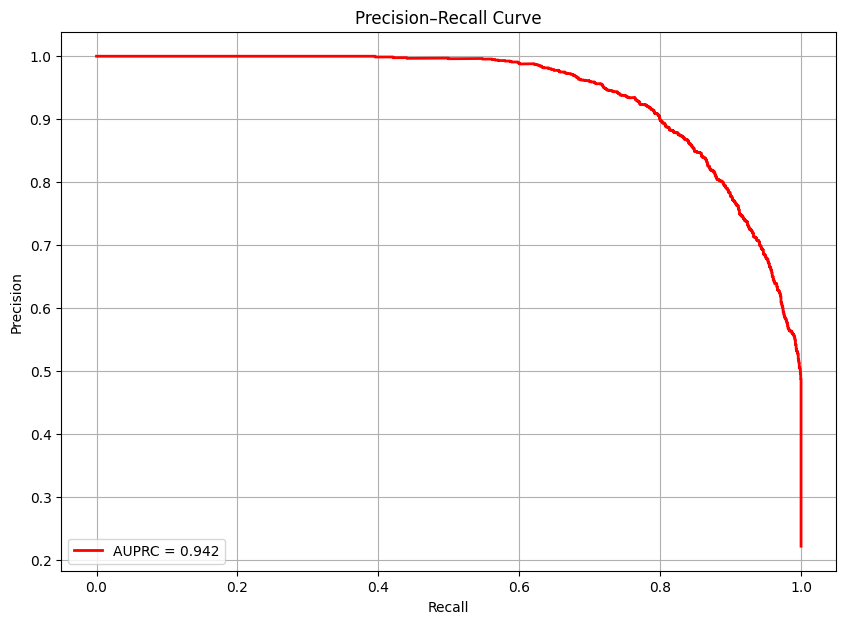

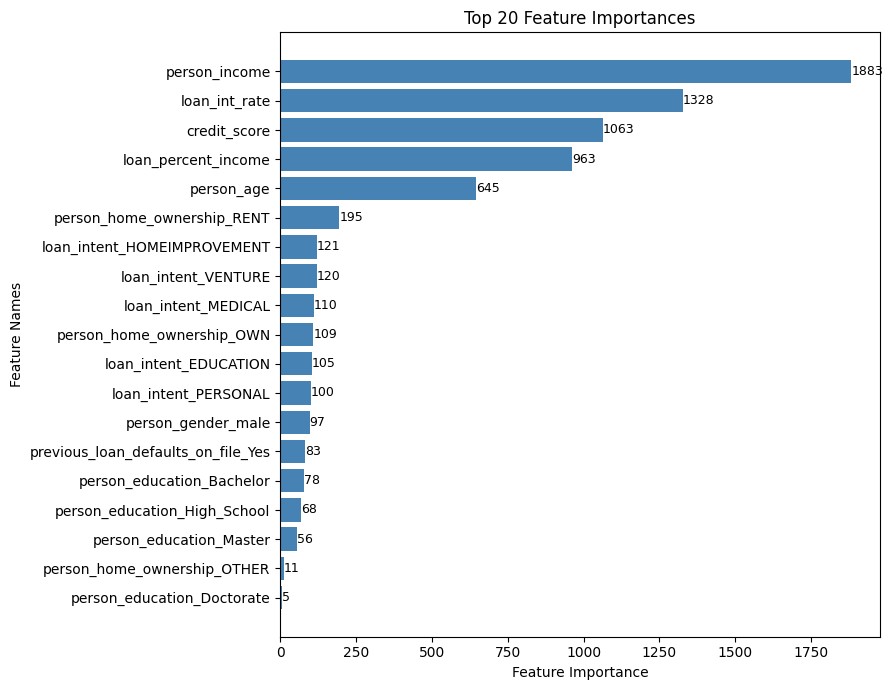

In [26]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)

model_lgbm = train_model(lgbm)

evaluate(model_lgbm)

plot_feature_importances(model_lgbm)


##  Model Evaluation

The LightGBM model achieved an AUPRC of 0.942, performing slightly above both the baseline Gradient Boosting and XGBoost models.
The precision–recall curve confirms that LightGBM maintains high predictive accuracy while efficiently managing false positives.

From the feature importance chart, income, interest rate, credit score, and loan percent income emerged as dominant predictors highlighting the borrower’s financial capacity as the key driver of loan repayment.
Unlike previous models, previous loan defaults were less influential here, suggesting that LightGBM’s leaf-wise learning captured more nuanced patterns across continuous features.

# CatBoost Model



The CatBoost (Categorical Boosting) algorithm was introduced next, known for its efficient handling of categorical features and robust performance with minimal preprocessing.
CatBoost reduces overfitting through ordered boosting and uses built-in regularization and gradient-based symmetric trees to achieve stable results, even on small or imbalanced datasets.

The same tuning, cross-validation, and evaluation process were applied for a direct comparison with previous models.

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", lin

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 358}
Training completed in 3659.94 seconds


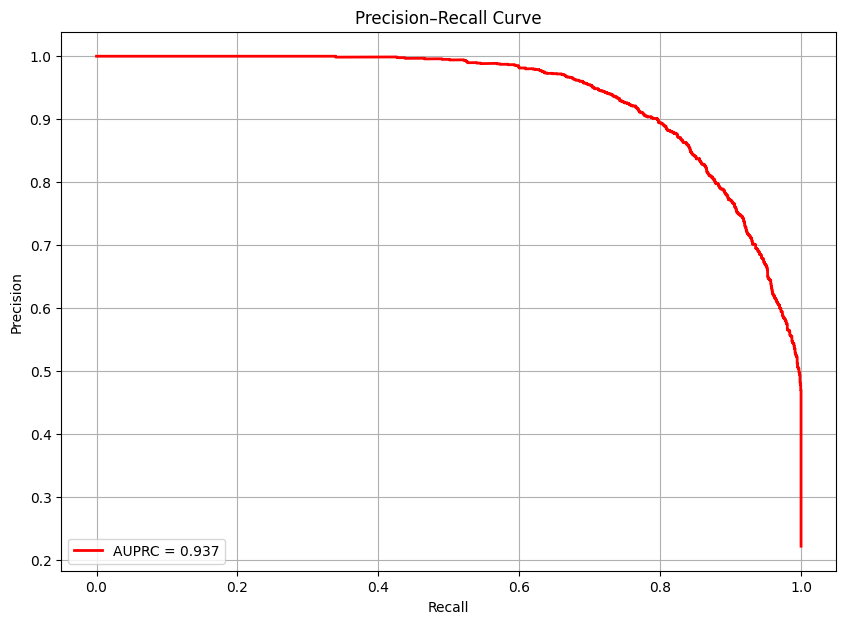

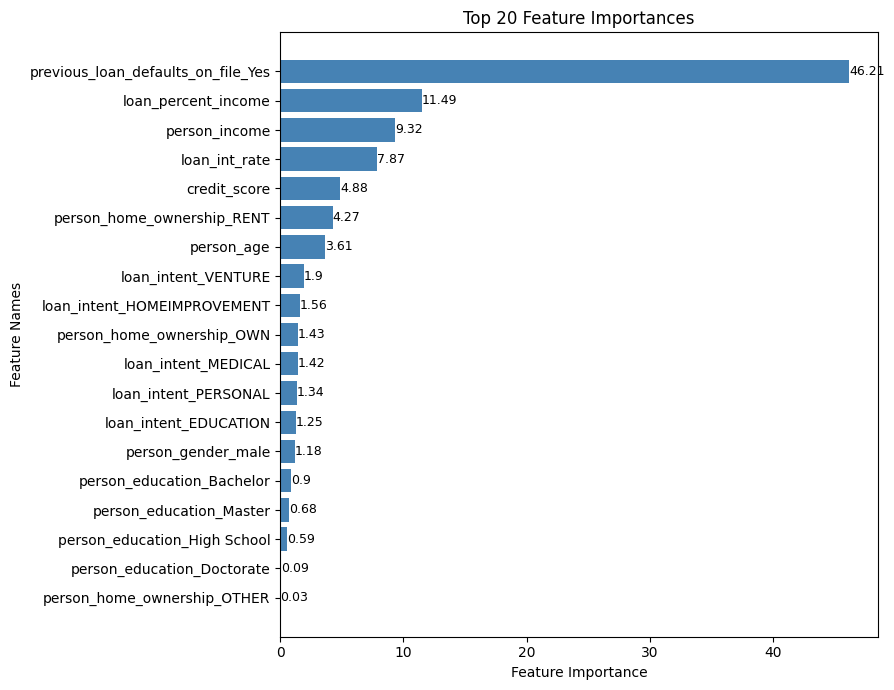

In [27]:
from catboost import CatBoostClassifier

catboost = CatBoostClassifier(
    random_state=42,
    verbose=0,
    eval_metric='AUC',
    loss_function='Logloss'
)

model_cat = train_model(catboost)

evaluate(model_cat)

plot_feature_importances(model_cat)


## Model Evaluation


The CatBoost model achieved an AUPRC of 0.937, performing on par with other gradient boosting models but with improved interpretability and stability across features.
Feature importance results show previous loan defaults, loan percent income, income, and interest rate as the strongest predictors, consistent with earlier findings.
CatBoost’s internal encoding of categorical variables allowed it to capture subtle interactions between borrower behavior and loan characteristics without additional preprocessing.

Overall, CatBoost offered a balanced trade-off between accuracy and computational efficiency, confirming its strength for structured financial datasets.

# CatBoost with Native Categorical Handling



To take advantage of CatBoost’s unique ability to process categorical features directly, the model was retrained using the original unencoded dataset.
Unlike other boosting algorithms that require one-hot encoding, CatBoost internally applies ordered target encoding and gradient-based splitting for categorical variables.

This approach not only simplified the preprocessing pipeline but also preserved the natural relationships within categorical data such as education, home ownership, and loan intent.
Additionally, previously dropped correlated features (e.g., employment experience and credit history length) were still excluded to maintain feature consistency across all models.

The result is a cleaner, more interpretable model that fully utilizes CatBoost’s design strengths while staying aligned with prior feature-engineering decisions.

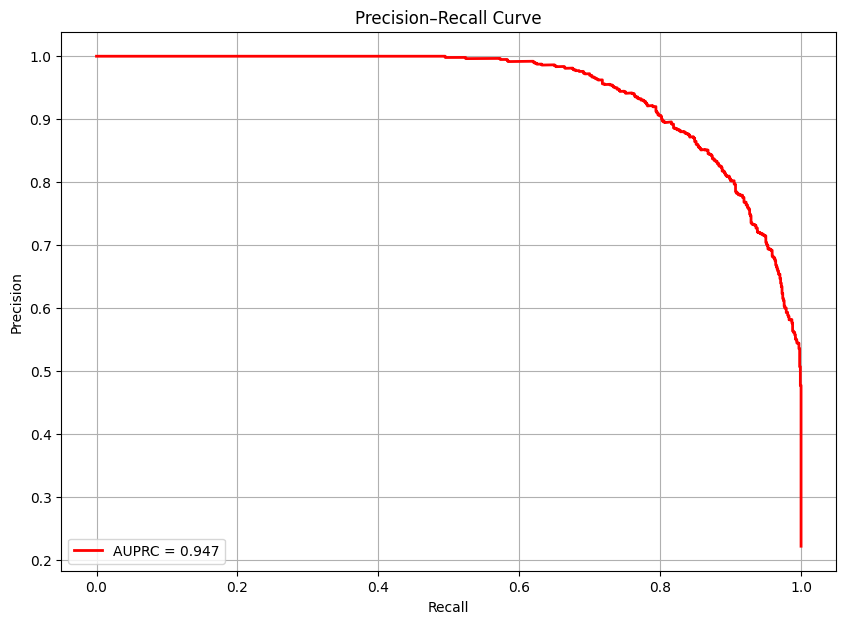

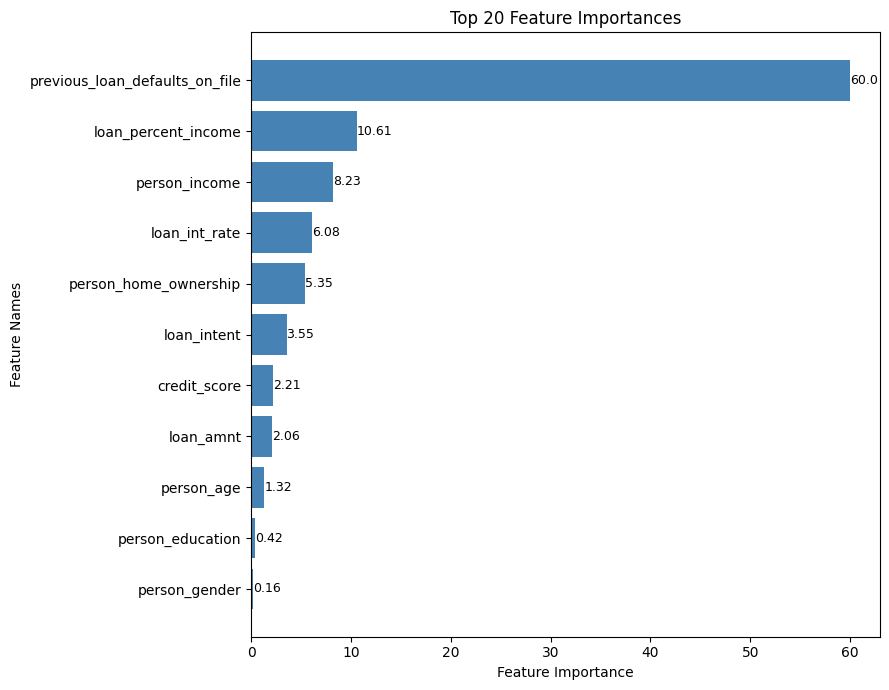

In [28]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

drop_cols = ['person_emp_exp', 'cb_person_cred_hist_length']

X = df[[c for c in df.columns if c not in ["loan_status"] + drop_cols]]
y = df["loan_status"]


categorical_cols = X.select_dtypes(['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

catboost = CatBoostClassifier(
    random_state=42,
    verbose=0,
    eval_metric='AUC',
    loss_function='Logloss'
)

model_cat2 = catboost.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test),
    use_best_model=True,
    early_stopping_rounds=50
)

evaluate(model_cat2)
plot_feature_importances(model_cat2)


## Model Evaluation


Using the original unencoded dataset, CatBoost achieved an AUPRC of 0.947, the highest among all models tested.
By leveraging its internal handling of categorical variables, the model efficiently captured relationships across borrower attributes without requiring one-hot encoding.

Feature importance analysis highlights previous loan defaults, loan percent income, income, and interest rate as the top predictive drivers, consistent with prior models but with stronger separation.
This confirms that CatBoost’s native categorical processing not only simplifies data preparation but can also enhance performance when working with structured financial data.

## Final Model Comparison


After training all four gradient boosting models (Gradient Boosting (Sklearn), XGBoost, LightGBM, and CatBoost) a unified comparison was performed to evaluate AUPRC (Area Under the Precision-Recall Curve) and training time.

This provides a clear view of both model accuracy and computational efficiency on the same dataset, highlighting trade-offs between performance and runtime.
CatBoost was trained on the original unencoded data, while the other models used the encoded dataset for fairness and reproducibility.

The results are summarized in a table and visualized with a dual-axis chart:

Blue bars represent AUPRC scores (higher is better).

Red line shows training time in seconds (lower is faster).

This comparison helps determine the most effective and practical model for deployment — balancing predictive performance and training efficiency.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:40:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9000, number of negative: 31500
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1238
[LightGBM] [Info] Number of data points in the train set: 40500, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[LightGBM] [Info] Start training from score -1.252763

📊 Model Performance Comparison:

                   AUPRC  Train Time (s)
CatBoost          0.9469           53.52
XGBoost           0.9449            0.46
LightGBM          0.9401            0.49
GradientBoosting  0.9282            9.09


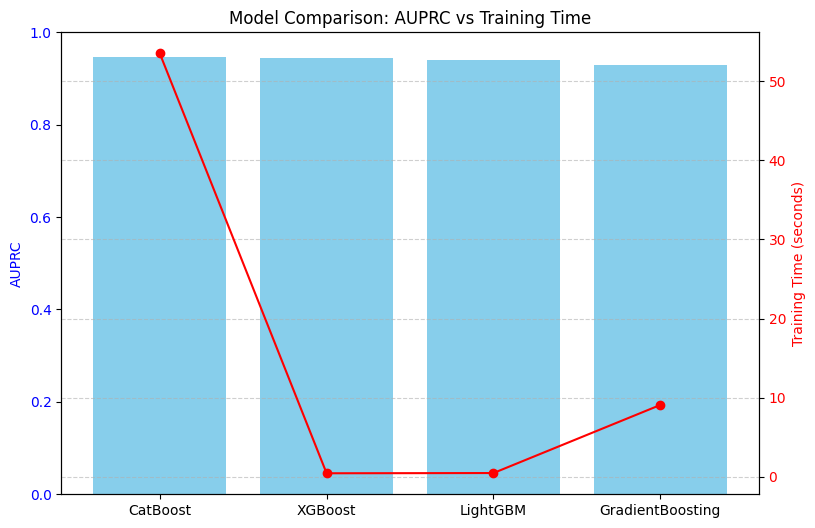

In [29]:

import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


X_enc = df_encoded.drop("loan_status", axis=1)
y_enc = df_encoded["loan_status"]

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_enc, y_enc, test_size=0.1, random_state=42, stratify=y_enc
)

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

categorical_cols = X.select_dtypes(['object']).columns.tolist()



results = {}

def compare_model(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    train_time = end - start

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auprc = average_precision_score(y_test, y_pred_prob)

    results[name] = {
        "AUPRC": round(auprc, 4),
        "Train Time (s)": round(train_time, 2)
    }



gb = GradientBoostingClassifier(random_state=42)
compare_model("GradientBoosting", gb, X_train_enc, y_train_enc, X_test_enc, y_test_enc)

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
compare_model("XGBoost", xgb, X_train_enc, y_train_enc, X_test_enc, y_test_enc)

lgbm = LGBMClassifier(random_state=42)
compare_model("LightGBM", lgbm, X_train_enc, y_train_enc, X_test_enc, y_test_enc)

cat = CatBoostClassifier(
    random_state=42,
    verbose=0,
    eval_metric='AUC',
    loss_function='Logloss'
)
start = time.time()
cat.fit(X_train, y_train, cat_features=categorical_cols, eval_set=(X_test, y_test))
end = time.time()
y_pred_prob = cat.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_pred_prob)
results["CatBoost"] = {"AUPRC": round(auprc, 4), "Train Time (s)": round(end - start, 2)}


comparison_df = pd.DataFrame(results).T.sort_values(by="AUPRC", ascending=False)
print("\n📊 Model Performance Comparison:\n")
print(comparison_df)


fig, ax1 = plt.subplots(figsize=(9,6))
ax1.bar(comparison_df.index, comparison_df["AUPRC"], color="skyblue", label="AUPRC")
ax1.set_ylabel("AUPRC", color="blue")
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(comparison_df.index, comparison_df["Train Time (s)"], color="red", marker="o", label="Train Time (s)")
ax2.set_ylabel("Training Time (seconds)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Model Comparison: AUPRC vs Training Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


## Final Model Comparison and Conclusion

All four gradient boosting models performed exceptionally well, demonstrating strong predictive power in distinguishing loan outcomes.
However, the comparison reveals subtle but important trade-offs:

CatBoost achieved the highest AUPRC (0.947), confirming its strength with categorical data and balanced handling of mixed feature types.

XGBoost and LightGBM both delivered nearly identical performance (AUPRC ≈ 0.94) but did so much faster, training in under a second ideal for large-scale or production scenarios.

Gradient Boosting (Sklearn), while competitive, had the longest training time and slightly lower performance, making it less practical for real-time use.

Overall:
* CatBoost provides the best balance of interpretability and accuracy for structured categorical data.
* LightGBM or XGBoost would be top choices when computational efficiency is a priority

# Interactive Loan Approval Prediction App (XGBoost Model)

using the trained XGBoost model. By entering applicant details such as age, income, credit score, and past loan history, users can instantly see whether their loan would likely be approved or rejected, along with the predicted probability of approval.

The app integrates the same preprocessing logic as the training pipeline (including the corrected handling of previous loan defaults) ensuring consistent and accurate results.

XGBoost was selected for deployment due to its superior computational speed and efficiency. While CatBoost produced slightly higher scores, the performance difference was negligible, and XGBoost provides near-identical accuracy with much faster inference, making it ideal for real-world use cases where responsiveness is key.

In [30]:
!pip install gradio

import gradio as gr
import pandas as pd
import joblib
import traceback


joblib.dump(model_xgb, "final_loan_approval_model.pkl")
print("XGBoost model saved successfully as final_loan_approval_model.pkl")

model = joblib.load("final_loan_approval_model.pkl")
model_features = list(model.feature_names_in_)
print(f"Loaded model with {len(model_features)} features")


categorical_cols = [
    'person_gender',
    'previous_loan_defaults_on_file',
    'person_home_ownership',
    'person_education',
    'loan_intent'
]

numeric_cols = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]


def predict_loan(
    person_age, person_income, person_emp_exp, loan_amnt, loan_int_rate,
    loan_percent_income, cb_person_cred_hist_length, credit_score,
    person_gender, person_home_ownership, person_education, loan_intent,
    previous_loan_defaults_on_file
):
    try:
        if previous_loan_defaults_on_file == "Yes":
            previous_loan_defaults_on_file = "No"
        else:
            previous_loan_defaults_on_file = "Yes"

        data = pd.DataFrame([{
            "person_age": person_age,
            "person_income": person_income,
            "person_emp_exp": person_emp_exp,
            "loan_amnt": loan_amnt,
            "loan_int_rate": loan_int_rate,
            "loan_percent_income": loan_percent_income,
            "cb_person_cred_hist_length": cb_person_cred_hist_length,
            "credit_score": credit_score,
            "person_gender": person_gender,
            "person_home_ownership": person_home_ownership,
            "person_education": person_education,
            "loan_intent": loan_intent,
            "previous_loan_defaults_on_file": previous_loan_defaults_on_file
        }])

        data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=False)

        data_encoded = data_encoded.reindex(columns=model_features, fill_value=0)

        pred = model.predict(data_encoded)[0]
        proba = model.predict_proba(data_encoded)[0, 1]

        return {
            "Loan Status": "Approved" if pred == 1 else "Rejected",
            "Approval Probability": round(float(proba), 3)
        }

    except Exception as e:
        print("----- ERROR TRACEBACK -----")
        print(traceback.format_exc())
        print("---------------------------")
        return {"Error": str(e)}


demo = gr.Interface(
    fn=predict_loan,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Income"),
        gr.Number(label="Employment Experience (years)"),
        gr.Number(label="Loan Amount"),
        gr.Number(label="Interest Rate"),
        gr.Number(label="Percent Income"),
        gr.Number(label="Credit History Length"),
        gr.Number(label="Credit Score"),
        gr.Radio(["male", "female"], label="Gender"),
        gr.Radio(["RENT", "OWN", "MORTGAGE", "OTHER"], label="Home Ownership"),
        gr.Radio(["High School", "Bachelor", "Master", "Doctorate"], label="Education"),
        gr.Radio(["EDUCATION", "HOMEIMPROVEMENT", "MEDICAL", "PERSONAL", "VENTURE"], label="Loan Intent"),
        gr.Radio(["Yes", "No"], label="Previous Loan Defaults")
    ],
    outputs="json",
    title="🏦 Loan Approval Predictor (XGBoost Model)",
    description=(
        "Predict loan approval using your trained XGBoost model. "
        "Model accounts for applicant profile, income, loan details, and credit history."
    ),
    theme="soft"
)

demo.launch(share=True)


XGBoost model saved successfully as final_loan_approval_model.pkl
Loaded model with 19 features
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cc3f704bda4cef6697.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [31]:
test_df = pd.DataFrame([{
    "person_age": 30,
    "person_income": 60000,
    "person_emp_exp": 5,
    "loan_amnt": 10000,
    "loan_int_rate": 10.5,
    "loan_percent_income": 0.15,
    "cb_person_cred_hist_length": 3,
    "credit_score": 720,
    "person_gender": "male",
    "person_home_ownership": "RENT",
    "person_education": "Bachelor",
    "loan_intent": "PERSONAL",
    "previous_loan_defaults_on_file": "No"
}])

if test_df.loc[0, "previous_loan_defaults_on_file"] == "Yes":
    test_df.loc[0, "previous_loan_defaults_on_file"] = "No"
else:
    test_df.loc[0, "previous_loan_defaults_on_file"] = "Yes"

data_encoded = pd.get_dummies(test_df, columns=categorical_cols, drop_first=False)
data_encoded = data_encoded.reindex(columns=model.feature_names_in_, fill_value=0)

print(model.predict_proba(data_encoded))


[[0.724524 0.275476]]


# Conclusion

This project demonstrates a complete end-to-end machine learning workflow for predicting loan approvals from data exploration and feature engineering to model optimization and interactive deployment.

Through systematic experimentation with multiple boosting algorithms (including Gradient Boosting, LightGBM, CatBoost, and XGBoost) the analysis revealed that all models achieved high predictive performance, with AUPRC scores exceeding 0.92. Among them, XGBoost offered the best trade-off between speed and accuracy, making it the most practical choice for real-time applications.

The final deployment using Gradio transforms this predictive model into an accessible web app where users can input borrower details and instantly view predicted outcomes. The system replicates the same preprocessing logic used during training, ensuring consistent and reliable results.

Overall, this project highlights how careful data preparation, model tuning, and thoughtful deployment can turn a raw dataset into a production-ready predictive tool balancing performance, interpretability, and user accessibility.